In [1]:
# imports
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np

In [2]:
# import training and test data
data = open("data/splits_full.pkl", "rb")
[X_train, X_test, y_train, y_test] = pickle.load(data)

In [3]:
# clf = RandomForestClassifier(random_state=42)

# clf.fit(X_train, y_train)

# y_pred = clf.predict(X_test)

# print(classification_report(y_test, y_pred, target_names=["early", "late", "middle"]))

# ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=300; total time=   0.0s[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=100; total time=   0.0s
[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=300; total time=   0.0s
[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=400; total time=   0.0s
[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=200; total time=   0.0s

[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=200; total time=   0.0s
[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=300; total time=   0.0s
[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=100; total time=   0.0s
[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=100; total time=   0.0s
[CV] END max_depth=3, max_features=srqt, min_samples_leaf=1, n_estimators=300; total time=   0.0s
[CV] END max_depth=3

/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
240 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
105 fits failed with the following error:
Traceback (most recent call last):
  File "/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/sam_linux/miniconda3

Best params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 400}
Best score: 0.5846699507389163
              precision    recall  f1-score   support

       early       0.60      0.07      0.13        40
        late       0.56      0.99      0.72       121
      middle       0.00      0.00      0.00        58

    accuracy                           0.56       219
   macro avg       0.39      0.36      0.28       219
weighted avg       0.42      0.56      0.42       219



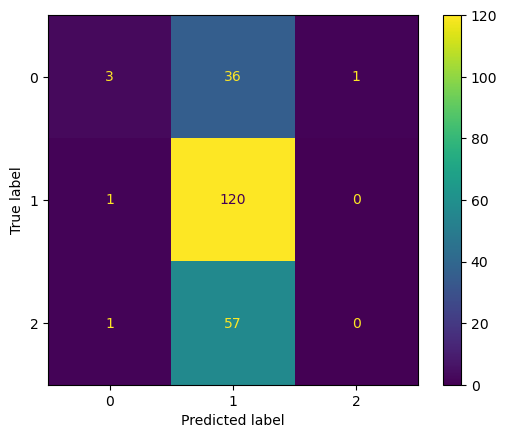

In [4]:
clf = RandomForestClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "n_estimators": [100, 200, 300, 400],
    "max_features": ["srqt", "log2"],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
)


grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

rf_optimized = grid_search.best_estimator_
y_pred = rf_optimized.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["early", "late", "middle"]))

ConfusionMatrixDisplay.from_estimator(grid_search, X_test, y_test)

In [5]:
start_time = time.time()
importances = rf_optimized.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf_optimized.estimators_], axis=0)
elapsed_time = time.time() - start_time

print(f"Elapsed time to compute the importances: {elapsed_time:.3f} seconds")

Elapsed time to compute the importances: 0.069 seconds


In [10]:
simple_features = [
    "GC_content",
    "gene_length",
    "start_atg",
    "protein_length",
    "H_frac",
    "E_frac",
    "C_frac",
    "rsa_mean",
    "frac_exposed",
    "transitions_per_residue",
    "molecular_weight",
    "aromaticity",
    "isoelectric_point",
]  # Simple features

feature_names = simple_features  # + [str(i) for i in range(13, 83)]  # with Kmers
# feature_names = simple_features + [str(i) for i in range(13, 1619)]  # with embeddings
# feature_names = [str(i) for i in range(1606)]  # Kmer + emb

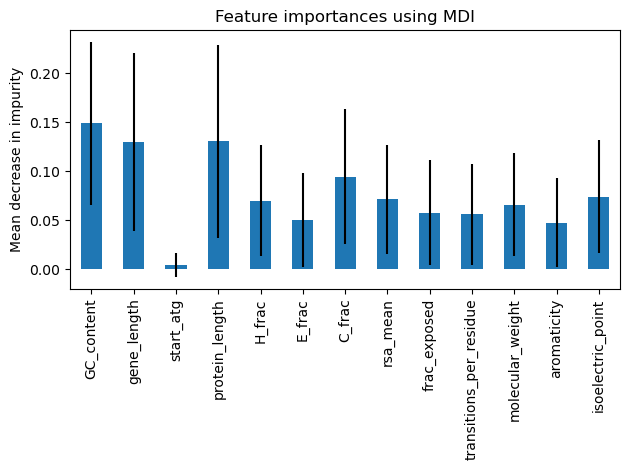

In [11]:
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

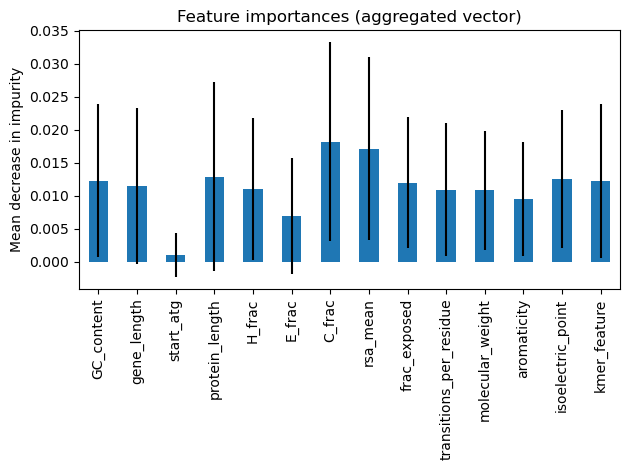

In [ ]:
## Simple + kmer
# Assuming feature_names is a list of all feature names in order
# vector_indices = np.arange(13, 83)  # Python ranges are exclusive on the right
# vector_mask = np.zeros(len(feature_names), dtype=bool)
# vector_mask[vector_indices] = True

# other_mask = ~vector_mask

# # Aggregate vector importance
# vector_importance = importances[vector_mask].mean()
# std_vector = std[vector_mask].mean()

# # Extract other feature data
# other_importances = importances[other_mask]
# other_stds = std[other_mask]
# other_names = np.array(feature_names)[other_mask]

# # Combine into a single summary series
# summary_importances = pd.Series(
#     list(other_importances) + [vector_importance],
#     index=list(other_names) + ["kmer_feature"],
# )
# summary_stds = list(other_stds) + [std_vector]

# # Plot
# fig, ax = plt.subplots()
# summary_importances.plot.bar(yerr=summary_stds, ax=ax)
# ax.set_title("Feature importances (aggregated vector)")
# ax.set_ylabel("Mean decrease in impurity")
# fig.tight_layout()
# plt.show()

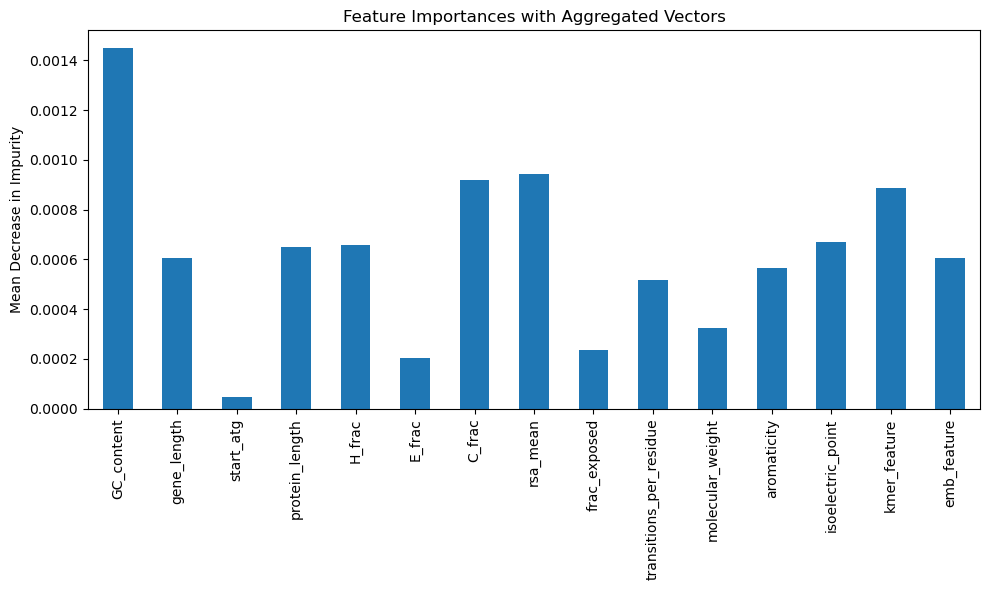

In [ ]:
# Full
vector1_indices = np.arange(13, 83)  # vector 1: inclusive range 12–82
vector2_indices = np.arange(83, 1619)  # vector 2: inclusive range 83–1619

vector_mask1 = np.zeros(len(feature_names), dtype=bool)
vector_mask2 = np.zeros(len(feature_names), dtype=bool)
vector_mask1[vector1_indices] = True
vector_mask2[vector2_indices] = True

# Combine vector masks
vector_mask = vector_mask1 | vector_mask2
other_mask = ~vector_mask

# Aggregate importances
vector1_importance = importances[vector_mask1].mean()
vector2_importance = importances[vector_mask2].mean()
vector1_std = std[vector_mask1].mean()
vector2_std = std[vector_mask2].mean()

# Other features
other_importances = importances[other_mask]
other_stds = std[other_mask]
other_names = np.array(feature_names)[other_mask]

# Combine into summary
summary_importances = pd.Series(
    list(other_importances) + [vector1_importance, vector2_importance],
    index=list(other_names) + ["kmer_feature", "emb_feature"],
)
summary_stds = list(other_stds)  # + [vector1_std, vector2_std]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
summary_importances.plot.bar(ax=ax)
ax.set_title("Feature Importances with Aggregated Vectors")
ax.set_ylabel("Mean Decrease in Impurity")
fig.tight_layout()
plt.show()

In [ ]:
# ## Kmer + emb
# vector1_indices = np.arange(0, 70)  # vector 1: inclusive range 12–82
# vector2_indices = np.arange(70, 1606)  # vector 2: inclusive range 83–1619

# vector_mask1 = np.zeros(len(feature_names), dtype=bool)
# vector_mask2 = np.zeros(len(feature_names), dtype=bool)
# vector_mask1[vector1_indices] = True
# vector_mask2[vector2_indices] = True

# # Combine vector masks
# vector_mask = vector_mask1 | vector_mask2
# other_mask = ~vector_mask

# # Aggregate importances
# vector1_importance = importances[vector_mask1].mean()
# vector2_importance = importances[vector_mask2].mean()
# vector1_std = std[vector_mask1].mean()
# vector2_std = std[vector_mask2].mean()

# # Other features
# other_importances = importances[other_mask]
# other_stds = std[other_mask]
# other_names = np.array(feature_names)[other_mask]

# # Combine into summary
# summary_importances = pd.Series(
#     list(other_importances) + [vector1_importance, vector2_importance],
#     index=list(other_names) + ["kmer_feature", "emb_feature"],
# )
# summary_stds = list(other_stds)  # + [vector1_std, vector2_std]

# # Plot
# fig, ax = plt.subplots(figsize=(10, 6))
# summary_importances.plot.bar(ax=ax)
# ax.set_title("Feature Importances with Aggregated Vectors")
# ax.set_ylabel("Mean Decrease in Impurity")
# fig.tight_layout()
# plt.show()

In [ ]:
bst = XGBClassifier(objective="binary:logistic", seed=42)

param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.1, 0.01, 0.05],
    "gamma": [0, 0.25, 1.0],
    "reg_lambda": [0, 1.0, 10.0],
}

optimal_params = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        seed=42,
        subsample=0.9,
        colsample_bytree=0.5,
        device="cuda",
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    verbose=0,
    n_jobs=10,
    cv=3,
)

/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [11:27:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/xgboost/core.py:729: UserWarning: [11:27:05] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for 

KeyboardInterrupt: 

              precision    recall  f1-score   support

       early       0.57      0.39      0.46        41
        late       0.69      0.93      0.79       126
      middle       0.33      0.13      0.19        52

    accuracy                           0.64       219
   macro avg       0.53      0.48      0.48       219
weighted avg       0.58      0.64      0.59       219



/home/sam_linux/miniconda3/envs/pha/lib/python3.13/site-packages/xgboost/core.py:729: UserWarning: [14:02:11] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


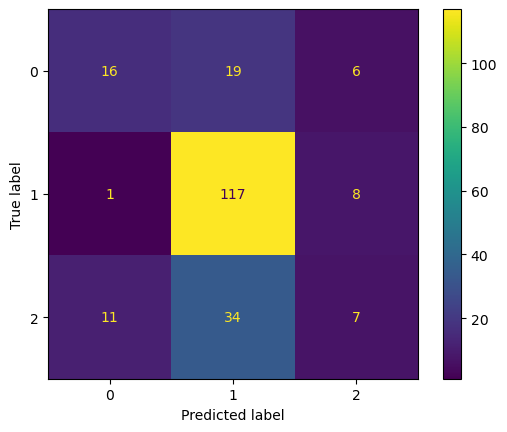

In [ ]:
optimal_params.fit(
    X_train,
    y_train,
    early_stopping_rounds=10,
    eval_metric="auc",
    eval_set=[(X_test, y_test)],
)

print(optimal_params.best_params_)

rf_optimized = optimal_params.best_estimator_
y_pred = rf_optimized.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["early", "late", "middle"]))

ConfusionMatrixDisplay.from_estimator(optimal_params, X_test, y_test)